# Listen what you won't — No Rewiring

## Objectives:
- Generate networks using Erdôs-Rényi and Barabási-Albert
- Apply the Hegselmann-Krause (HK) opinion dynamics 
- Analyze the behavior of opinion polarization with:
    - The difference between the 2 models
    - The evolution of polarization over time
    - The convergence point of different thresholds

In [14]:
# Imports

import os
import numpy as np
import matplotlib.pyplot as plt

os.getcwd()
os.chdir("/home/jovyan/work/CN_A4_FinalProject")
print(os.getcwd())
print(os.listdir())

from network_gen   import make_network, get_opinions
from hk_dynamics   import hk_run_history, opinion_variance, n_clusters, n_robust_clusters, polarization_index, robust_polarization_index
from simulation    import run_simulation, compute_metrics
from visualization import (
    plot_network_opinion,
    plot_network_community,
    plot_snapshots,
    plot_metrics,
    plot_opinion_histogram,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

/home/jovyan/work/CN_A4_FinalProject
['.git', '.gitignore', '01_basic_experiment.ipynb', '02_study_without_rewiring.ipynb', 'hk_dynamics.py', 'network_gen.py', 'README.md', 'repair.py', 'simulation.py', 'visualization.py', '__pycache__']


# First Experiment: Erdos-Renyi

In [15]:
graph_ER = make_network(
    model   = "ER",
    n       = 200,
    #m       = 3,
    opinion = "uniform",
    seed    = 42,
)

print(f"Nodes: {graph_ER.number_of_nodes()}")
print(f"Edges: {graph_ER.number_of_edges()}")
print(f"Graph average: {np.mean([d for _, d in graph_ER.degree()]):.2f}")
print(f"Initial average opinion: {get_opinions(graph_ER).mean():.3f}")
print(f"Initial variance: {get_opinions(graph_ER).var():.3f}")

Nodes: 200
Edges: 942
Graph average: 9.42
Initial average opinion: 0.494
Initial variance: 0.079


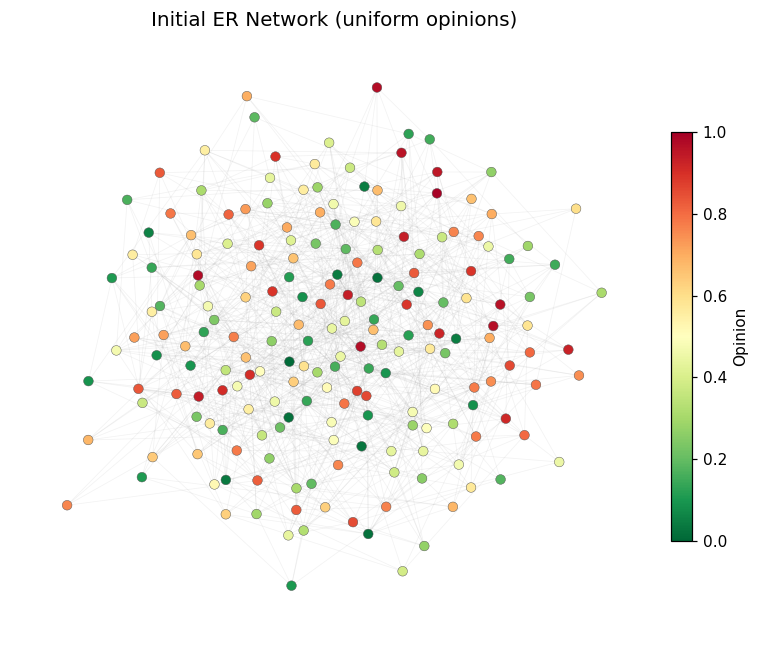

In [16]:
pos = plot_network_opinion(graph_ER, title="Initial ER Network (uniform opinions)", layout="spring")

In [17]:
epsilon = 0.05

result_hk_only = run_simulation(
    graph_ER,
    epsilon      = epsilon,
    rewire       = False,   # without rewiring
    max_hk_steps = 6000,
    seed         = 42,
)

op_initial  = result_hk_only["snapshots"][0][1]
op_converged = result_hk_only["snapshots"][1][1]

print(f"ε = {epsilon}")
print(f"Steps to convergence: {result_hk_only['phases'][0]['steps']}")
print(f"Opinion clusters: {n_clusters(op_converged)}")
print(f"Final variance: {opinion_variance(op_converged):.4f}")
print(f"Polarization Index: {polarization_index(op_converged):.4f}  (0=consenso, 1=máximo)")

ε = 0.05
Steps to convergence: 250
Opinion clusters: 90
Final variance: 0.0786
Polarization Index: 0.3145  (0=consenso, 1=máximo)


In [18]:
epsilons = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
variances = []
num_clusters = []

for eps in epsilons:
    r = run_simulation(graph_ER, epsilon=eps, rewire=False, max_hk_steps=6000, seed=42)
    final_op = r["snapshots"][-1][1]
    variances.append(opinion_variance(final_op))
    num_clusters.append(n_clusters(final_op))

# --- LÓGICA PARA DETECTAR LOS PUNTOS DE INFLEXIÓN ---
eps_polarization = None
eps_consensus = None

for eps, clusters in zip(epsilons, num_clusters):
    # Guardamos el primer epsilon donde detectamos exactamente 2 clusters
    if clusters == 2 and eps_polarization is None:
        eps_polarization = eps
    # Guardamos el primer epsilon donde detectamos consenso total (1 cluster)
    if clusters == 1 and eps_consensus is None:
        eps_consensus = eps

# Imprimir los resultados por consola
print("-" * 50)
if eps_polarization is not None:
    print(f"-> La POLARIZACIÓN (2 clusters) comienza en ε = {eps_polarization}")
else:
    print("-> No se detectó un estado de polarización exacta con estos epsilons.")

if eps_consensus is not None:
    print(f"-> El CONSENSO TOTAL (1 cluster) se alcanza en ε = {eps_consensus}")
else:
    print("-> No se alcanzó el consenso total con estos epsilons.")
print("-" * 50)


# --- GRÁFICOS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfico 1: Varianza
ax1.plot(epsilons, variances, "o-", color="#2166ac", linewidth=2, label="Variance")
ax1.set_xlabel("ε (epsilon)", fontsize=12)
ax1.set_ylabel("Opinion variance", fontsize=12)
ax1.set_title("Polarization vs. ε", fontsize=13)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Número de Clusters
ax2.plot(epsilons, num_clusters, "s-", color="#d6604d", linewidth=2, label="Clusters")
ax2.set_xlabel("ε (epsilon)", fontsize=12)
ax2.set_ylabel("Nº de clusters", fontsize=12)
ax2.set_title("Final clusters vs. ε", fontsize=13)
ax2.yaxis.get_major_locator().set_params(integer=True)
ax2.grid(True, alpha=0.3)

# --- AÑADIR LÍNEAS VERTICALES EN AMBOS GRÁFICOS ---
for ax in [ax1, ax2]:
    if eps_polarization is not None:
        ax.axvline(x=eps_polarization, color="#e6550d", linestyle="--", linewidth=1.5, 
                   label=f"Polarization (ε={eps_polarization})")
    if eps_consensus is not None:
        ax.axvline(x=eps_consensus, color="#31a354", linestyle="--", linewidth=1.5, 
                   label=f"Consensus (ε={eps_consensus})")

# Añadir la leyenda para identificar las líneas
ax1.legend(loc="best")
ax2.legend(loc="best")

plt.suptitle("Epsilon effect in HK (without rewiring)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_277/935216407.py", line 6, in <module>
    r = run_simulation(graph_ER, epsilon=eps, rewire=False, max_hk_steps=6000, seed=42)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jovyan/work/CN_A4_FinalProject/simulation.py", line 329, in run_simulation
    phase1 = _phase_burnin(G, epsilon, max_hk_steps, tol, record_every)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jovyan/work/CN_A4_FinalProject/simulation.py", line 106, in _phase_burnin
    metrics_list.append(compute_metrics(G))
                        ^^^^^^^^^^^^^^^^^^
  File "/home/jovyan/work/CN_A4_FinalProject/simulation.py", line 76, in compute_metrics
    partition = _louvain_partition(G)
                ^^^^^^^^^^^^^^^^

Graficando 118 iteraciones reales para ε = 0.10...


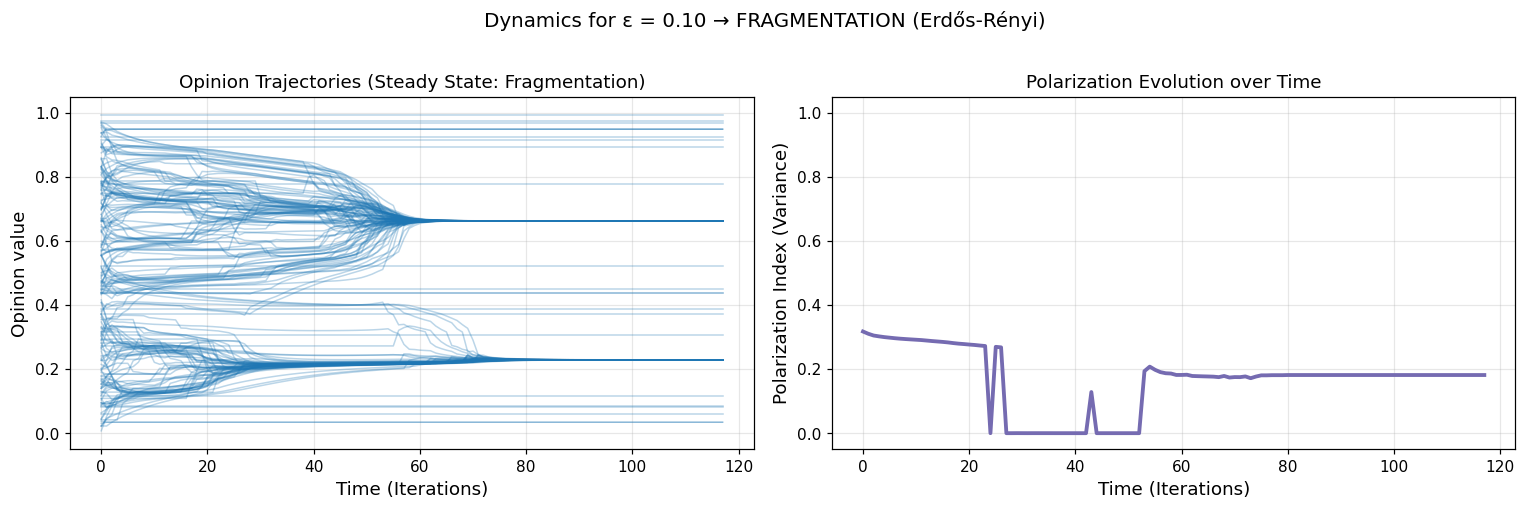

Graficando 31 iteraciones reales para ε = 0.25...


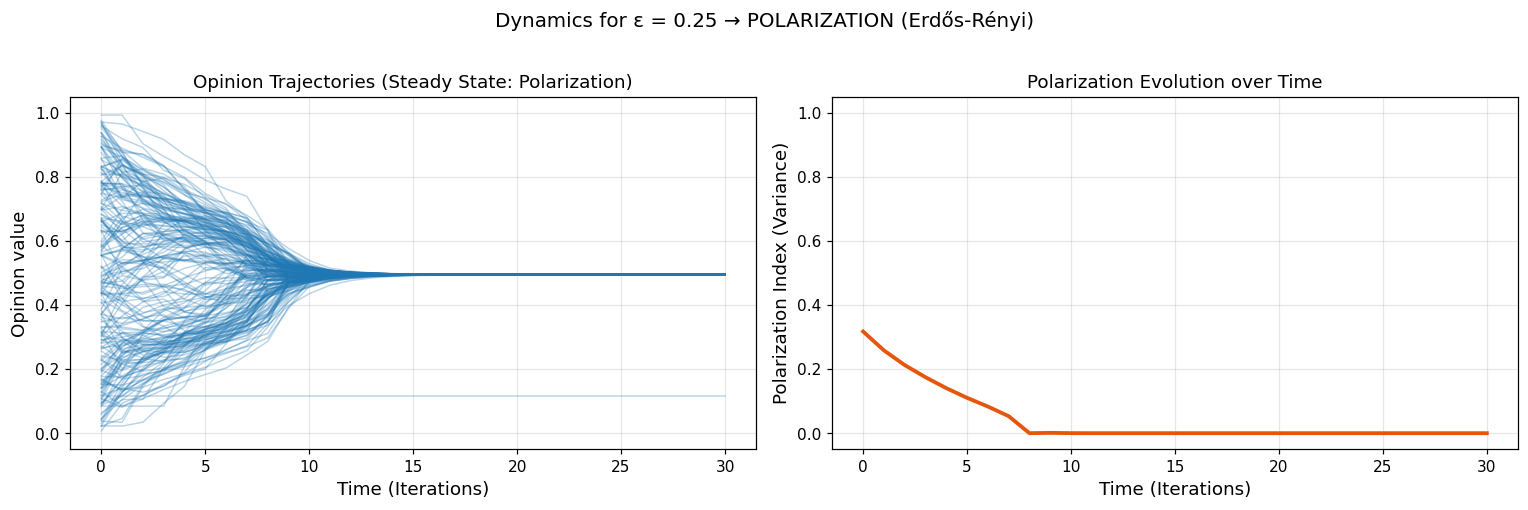

Graficando 27 iteraciones reales para ε = 0.35...


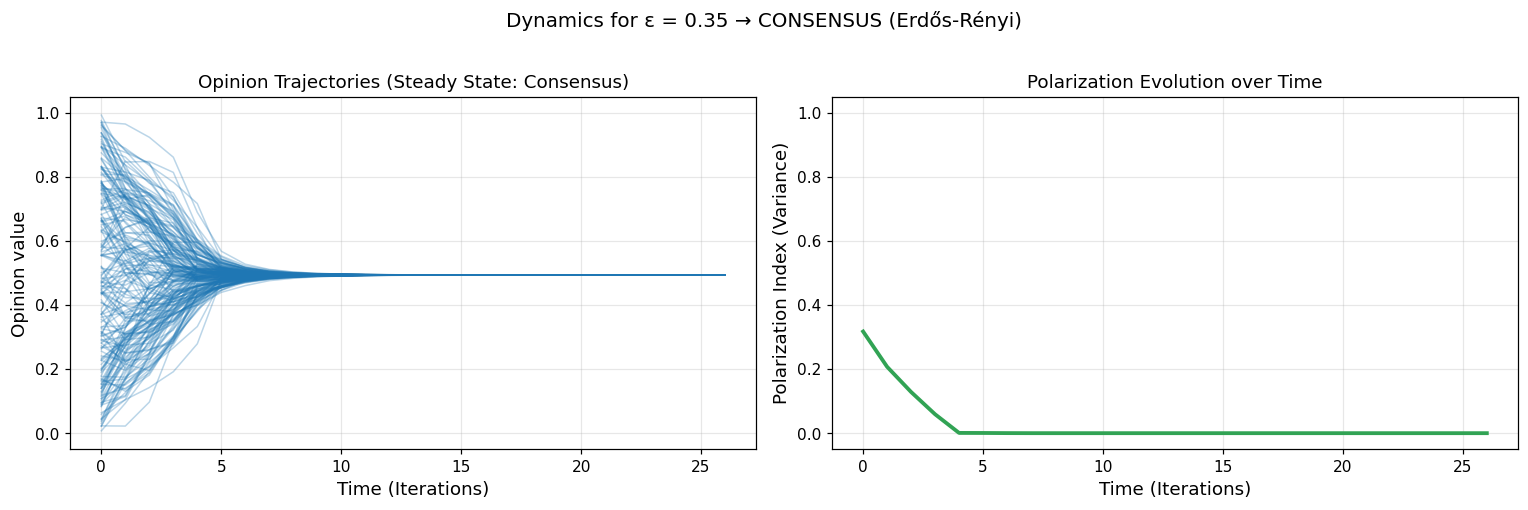

In [19]:
def plot_temporal_dynamics(graph, epsilon_val, regimen_name, color_var):
    """
    Ejecuta la simulación y grafica las trayectorias de opinión 
    y la varianza utilizando el historial completo del 'burn-in'.
    """
    # 1. Ejecutar simulación sin alterar nada de tu lógica original
    r = run_simulation(graph, epsilon=epsilon_val, rewire=False, max_hk_steps=6000, seed=42)
    
    # ACCESO CRUCIAL: Extraemos la historia real paso a paso de la Fase 1 (Burn-in)
    history = r["phases"][0]["history"]
    num_steps = len(history)
    num_nodes = graph.number_of_nodes()

    print(f"Graficando {num_steps} iteraciones reales para ε = {epsilon_val:.2f}...")

    # Matrices para almacenar el historial de dibujo basado en len(history)
    opinion_history = np.zeros((num_steps, num_nodes))
    variance_history = np.zeros(num_steps)
    time_steps = np.arange(num_steps)

    # Rellenamos los datos iterando sobre el verdadero histórico paso a paso
    for t in range(num_steps):
        opinions_at_t = history[t] 
        opinion_history[t, :] = opinions_at_t
        # Aplicamos tu nuevo filtro de polarización robusta
        variance_history[t] = robust_polarization_index(opinions_at_t, min_size_pct=0.05)

    # 2. Diseñar el par de gráficos
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

    # Gráfico izquierdo: Trayectorias (Eje X dinámico real de 0 a N pasos)
    ax1.plot(time_steps, opinion_history, color="#1f77b4", alpha=0.3, linewidth=1)
    ax1.set_xlabel("Time (Iterations)", fontsize=12)
    ax1.set_ylabel("Opinion value", fontsize=12)
    ax1.set_title(f"Opinion Trajectories (Steady State: {regimen_name})", fontsize=12)
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, alpha=0.3)

    # Gráfico derecho: Varianza robusta a lo largo del tiempo real
    ax2.plot(time_steps, variance_history, "-", color=color_var, linewidth=2.5)
    ax2.set_xlabel("Time (Iterations)", fontsize=12)
    ax2.set_ylabel("Polarization Index (Variance)", fontsize=12)
    ax2.set_title(f"Polarization Evolution over Time", fontsize=12)
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(True, alpha=0.3)

    # Título principal del par de gráficas
    plt.suptitle(f"Dynamics for ε = {epsilon_val:.2f} → {regimen_name.upper()} (Erdős-Rényi)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

# =====================================================================
# EJECUTAR LAS TRES CONFIGURACIONES INTERESANTES
# =====================================================================

# 1. Fragmentación (ε = 0.10)
plot_temporal_dynamics(graph_ER, epsilon_val=0.10, regimen_name="Fragmentation", color_var="#756bb1")

# 2. Polarización (ε = 0.25)
plot_temporal_dynamics(graph_ER, epsilon_val=0.25, regimen_name="Polarization", color_var="#e6550d")

# 3. Consenso (ε = 0.35)
plot_temporal_dynamics(graph_ER, epsilon_val=0.35, regimen_name="Consensus", color_var="#31a354")

ε = 0.25
Steps to convergence: 30
Opinion clusters: 2
Final variance: 0.0007
Polarization Index: 0.0029  (0=consenso, 1=máximo)


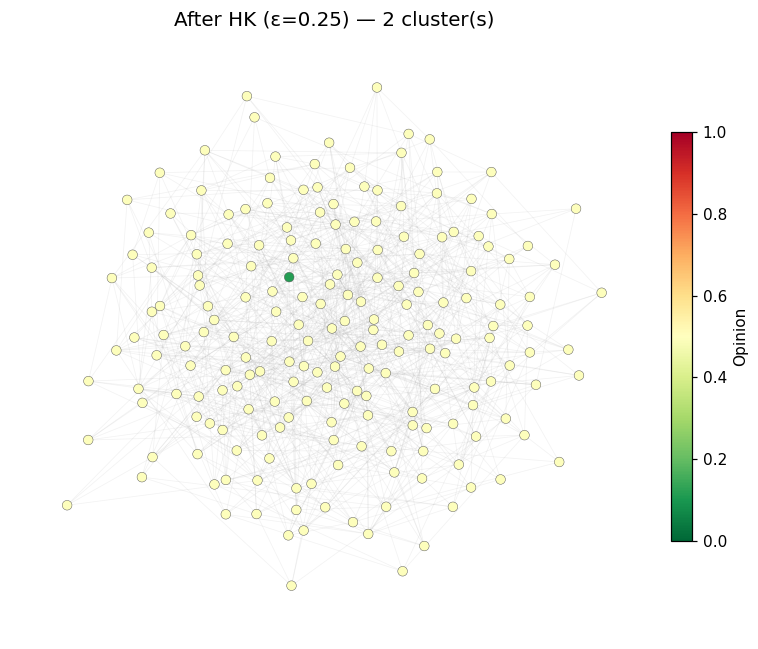

{0: array([ 0.48477126, -0.21046029]),
 1: array([-0.15229073, -0.79938717]),
 2: array([ 0.11500113, -0.24402593]),
 3: array([-0.294237  ,  0.95022302]),
 4: array([-0.48727886, -0.12327965]),
 5: array([-0.46163077,  0.23595052]),
 6: array([-0.91011343, -0.67952761]),
 7: array([ 0.03954634, -0.27457432]),
 8: array([0.25987414, 0.79975958]),
 9: array([0.53312757, 0.35136485]),
 10: array([0.3745366, 0.3883049]),
 11: array([ 0.80695436, -0.05977517]),
 12: array([-0.61733903, -0.48779155]),
 13: array([-0.2579955 , -0.58068113]),
 14: array([-0.00271788,  0.02465097]),
 15: array([ 0.38517479, -0.07366197]),
 16: array([-0.43814863,  0.73458375]),
 17: array([0.29336297, 0.17045672]),
 18: array([-0.12504562, -0.69830924]),
 19: array([-0.36650863, -0.71554254]),
 20: array([ 0.01822772, -0.51933058]),
 21: array([-0.36682772, -0.14130418]),
 22: array([0.15138016, 0.98476405]),
 23: array([0.25319613, 0.11978912]),
 24: array([ 0.49076647, -0.40573565]),
 25: array([0.04465358, 

In [ ]:
epsilon = 0.25

result_ek_polarization = run_simulation(
    graph_ER,
    epsilon      = epsilon,
    rewire       = False,   # without rewiring
    max_hk_steps = 6000,
    seed         = 42,
)

op_initial  = result_ek_polarization["snapshots"][0][1]
op_converged = result_ek_polarization["snapshots"][1][1]

print(f"ε = {epsilon}")
print(f"Steps to convergence: {result_ek_polarization['phases'][0]['steps']}")
print(f"Opinion clusters: {n_clusters(op_converged)}")
print(f"Final variance: {opinion_variance(op_converged):.4f}")
print(f"Polarization Index: {polarization_index(op_converged):.4f}  (0=consenso, 1=máximo)")

plot_network_opinion(
    result_ek_polarization["G"],
    opinions = op_converged,
    title    = f"After HK (ε={epsilon}) — {n_clusters(op_converged)} cluster(s)",
    pos      = pos,
)

# Analisis resultados
Como podemos ver, se supone que con un epsilon = 0.25, se llega a una polarizacion, pero en realidad hay un nodo con una opinion diferente de todos los demás. 

Si definimos la polarizacion como el estado estacionario en donde la poblacion llega a 2 opiniones diferentes, esto es correcto.
Pero si queremos ser más especificos y que se generen 2 grupos con opiniones diferentes y no personas aisladas, tenemos que ser más concretos. 

La nueva definicion de cluster requiere que la poblacion de una opinion represente como minimo el 5% de la poblacion total

--------------------------------------------------
-> La POLARIZACIÓN MACRO (2 clústeres significativos) comienza en ε = 0.1
-> El CONSENSO MACRO (1 clúster mayoritario) se alcanza en ε = 0.175
--------------------------------------------------


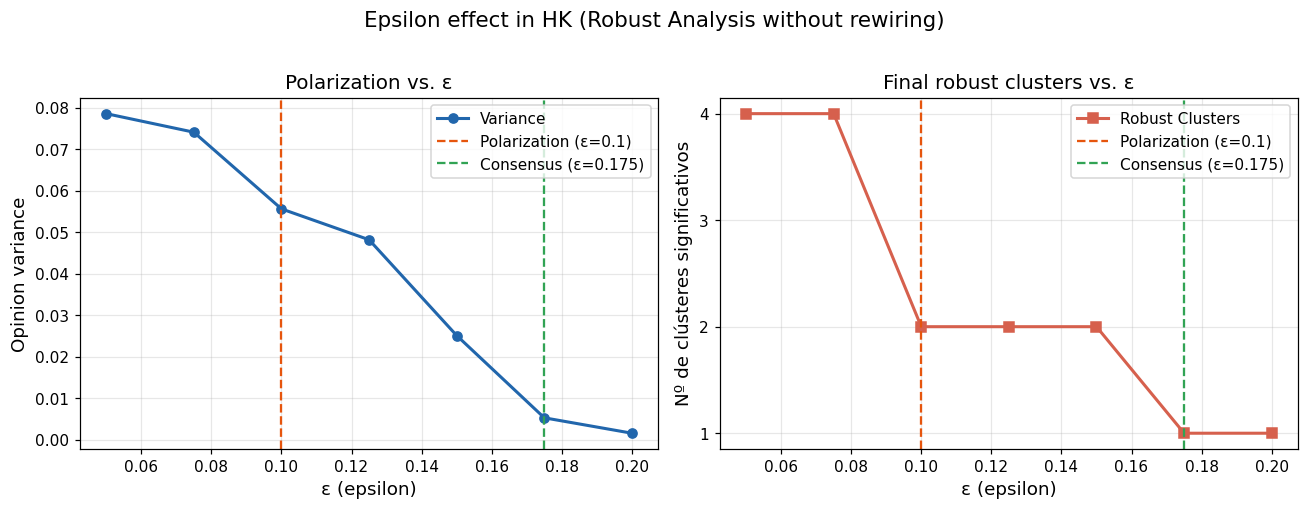

In [ ]:
# =====================================================================
# SIMULACIÓN ACTUALIZADA CON FILTRO ROBUSTO
# =====================================================================
epsilons = [0.05, 0.075, 0.1, 0.125, 0.150, 0.175, 0.2]
variances = []
num_clusters = []

for eps in epsilons:
    r = run_simulation(graph_ER, epsilon=eps, rewire=False, max_hk_steps=6000, seed=42)
    final_op = r["snapshots"][-1][1]
    variances.append(opinion_variance(final_op))
    
    # !!! AQUÍ USAMOS LA NUEVA FUNCIÓN ROBUSTA (Masa mínima: 5% de la red)
    num_clusters.append(n_robust_clusters(final_op, min_size_pct=0.05))

# --- LÓGICA PARA DETECTAR LOS PUNTOS DE INFLEXIÓN ---
eps_polarization = None
eps_consensus = None

for eps, clusters in zip(epsilons, num_clusters):
    if clusters == 2 and eps_polarization is None:
        eps_polarization = eps
    if clusters == 1 and eps_consensus is None:
        eps_consensus = eps

# Imprimir los resultados por consola
print("-" * 50)
if eps_polarization is not None:
    print(f"-> La POLARIZACIÓN MACRO (2 clústeres significativos) comienza en ε = {eps_polarization}")
else:
    print("-> No se detectó un estado de polarización real (mitades significativas) con estos epsilons.")

if eps_consensus is not None:
    print(f"-> El CONSENSO MACRO (1 clúster mayoritario) se alcanza en ε = {eps_consensus}")
else:
    print("-> No se alcanzó el consenso macro con estos epsilons.")
print("-" * 50)

# --- GRÁFICOS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfico 1: Varianza
ax1.plot(epsilons, variances, "o-", color="#2166ac", linewidth=2, label="Variance")
ax1.set_xlabel("ε (epsilon)", fontsize=12)
ax1.set_ylabel("Opinion variance", fontsize=12)
ax1.set_title("Polarization vs. ε", fontsize=13)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Número de Clusters
ax2.plot(epsilons, num_clusters, "s-", color="#d6604d", linewidth=2, label="Robust Clusters")
ax2.set_xlabel("ε (epsilon)", fontsize=12)
ax2.set_ylabel("Nº de clústeres significativos", fontsize=12)
ax2.set_title("Final robust clusters vs. ε", fontsize=13)
ax2.yaxis.get_major_locator().set_params(integer=True)
ax2.grid(True, alpha=0.3)

# --- AÑADIR LÍNEAS VERTICALES EN AMBOS GRÁFICOS ---
for ax in [ax1, ax2]:
    if eps_polarization is not None:
        ax.axvline(x=eps_polarization, color="#e6550d", linestyle="--", linewidth=1.5, 
                   label=f"Polarization (ε={eps_polarization})")
    if eps_consensus is not None:
        ax.axvline(x=eps_consensus, color="#31a354", linestyle="--", linewidth=1.5, 
                   label=f"Consensus (ε={eps_consensus})")

ax1.legend(loc="best")
ax2.legend(loc="best")

plt.suptitle("Epsilon effect in HK (Robust Analysis without rewiring)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Con esta nueva definicion vemos que la polarizacion y el consenso ocurren con valores mucho menores.

Ahora haremos zoom y veremos el epsilon donde ocurre la polarizacion y el consenso

--------------------------------------------------
-> La POLARIZACIÓN MACRO (2 clústeres significativos) comienza en ε = 0.09
-> El CONSENSO MACRO (1 clúster mayoritario) se alcanza en ε = 0.18
--------------------------------------------------


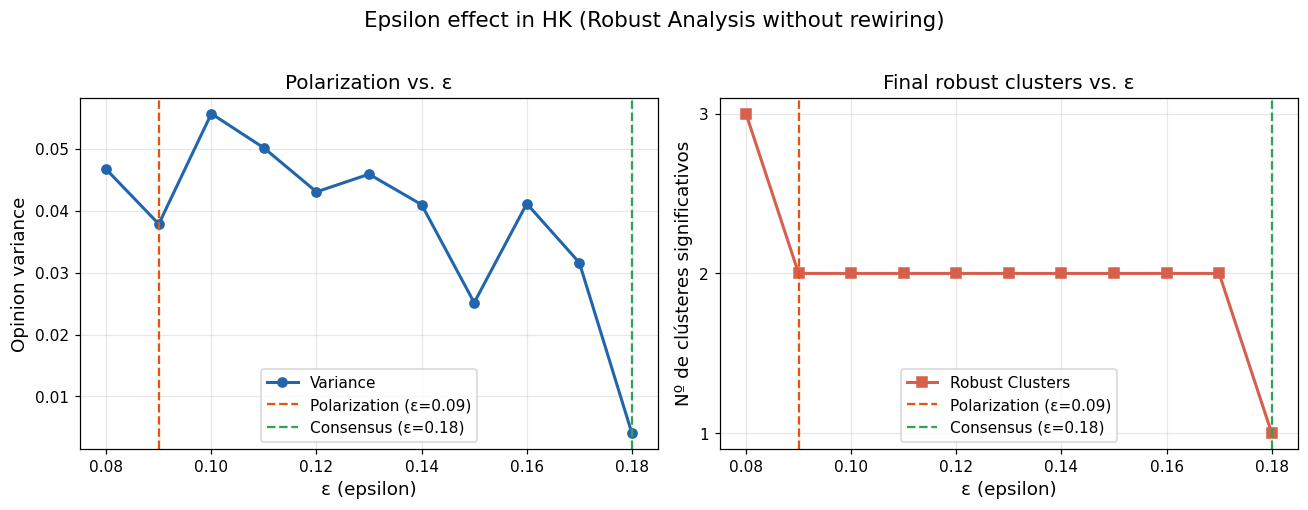

In [ ]:
epsilons = [0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18]
variances = []
num_clusters = []

for eps in epsilons:
    r = run_simulation(graph_ER, epsilon=eps, rewire=False, max_hk_steps=6000, seed=42)
    final_op = r["snapshots"][-1][1]
    variances.append(opinion_variance(final_op))
    
    # !!! AQUÍ USAMOS LA NUEVA FUNCIÓN ROBUSTA (Masa mínima: 5% de la red)
    num_clusters.append(n_robust_clusters(final_op, min_size_pct=0.05))

# --- LÓGICA PARA DETECTAR LOS PUNTOS DE INFLEXIÓN ---
eps_polarization = None
eps_consensus = None

for eps, clusters in zip(epsilons, num_clusters):
    if clusters == 2 and eps_polarization is None:
        eps_polarization = eps
    if clusters == 1 and eps_consensus is None:
        eps_consensus = eps

# Imprimir los resultados por consola
print("-" * 50)
if eps_polarization is not None:
    print(f"-> La POLARIZACIÓN MACRO (2 clústeres significativos) comienza en ε = {eps_polarization}")
else:
    print("-> No se detectó un estado de polarización real (mitades significativas) con estos epsilons.")

if eps_consensus is not None:
    print(f"-> El CONSENSO MACRO (1 clúster mayoritario) se alcanza en ε = {eps_consensus}")
else:
    print("-> No se alcanzó el consenso macro con estos epsilons.")
print("-" * 50)

# --- GRÁFICOS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfico 1: Varianza
ax1.plot(epsilons, variances, "o-", color="#2166ac", linewidth=2, label="Variance")
ax1.set_xlabel("ε (epsilon)", fontsize=12)
ax1.set_ylabel("Opinion variance", fontsize=12)
ax1.set_title("Polarization vs. ε", fontsize=13)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Número de Clusters
ax2.plot(epsilons, num_clusters, "s-", color="#d6604d", linewidth=2, label="Robust Clusters")
ax2.set_xlabel("ε (epsilon)", fontsize=12)
ax2.set_ylabel("Nº de clústeres significativos", fontsize=12)
ax2.set_title("Final robust clusters vs. ε", fontsize=13)
ax2.yaxis.get_major_locator().set_params(integer=True)
ax2.grid(True, alpha=0.3)

# --- AÑADIR LÍNEAS VERTICALES EN AMBOS GRÁFICOS ---
for ax in [ax1, ax2]:
    if eps_polarization is not None:
        ax.axvline(x=eps_polarization, color="#e6550d", linestyle="--", linewidth=1.5, 
                   label=f"Polarization (ε={eps_polarization})")
    if eps_consensus is not None:
        ax.axvline(x=eps_consensus, color="#31a354", linestyle="--", linewidth=1.5, 
                   label=f"Consensus (ε={eps_consensus})")

ax1.legend(loc="best")
ax2.legend(loc="best")

plt.suptitle("Epsilon effect in HK (Robust Analysis without rewiring)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

ε = 0.1
Steps to convergence: 117
Opinion clusters: 21
Final variance: 0.0557
Polarization Index: 0.2227  (0=consenso, 1=máximo)


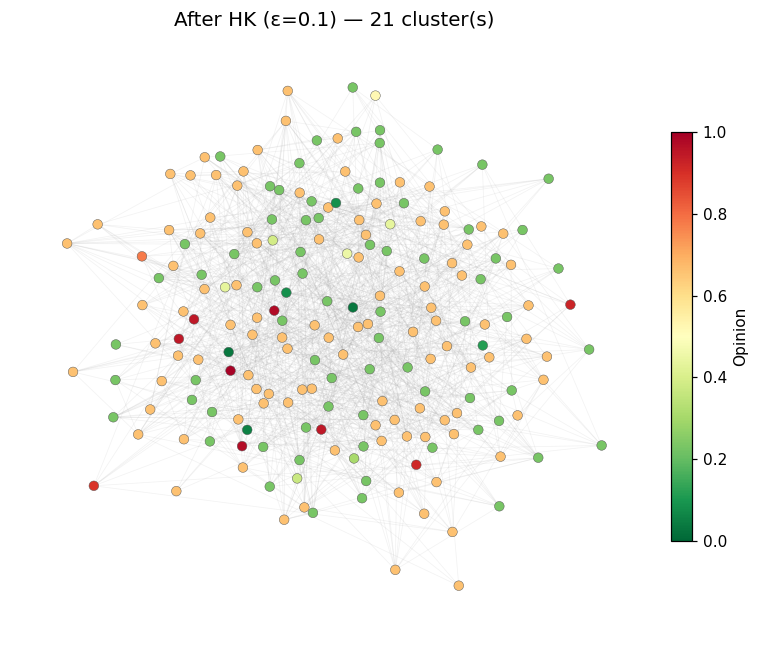

{0: array([-0.07373056, -0.01562609]),
 1: array([0.15390746, 0.03580438]),
 2: array([-0.16552616, -0.3078493 ]),
 3: array([ 0.07622883, -0.02200432]),
 4: array([-0.03058896,  0.07533486]),
 5: array([-0.21329791,  0.03991436]),
 6: array([-0.02519338, -0.06254404]),
 7: array([ 0.11016257, -0.01077144]),
 8: array([-0.11562541,  0.17995265]),
 9: array([0.03861791, 0.25513176]),
 10: array([ 0.14793079, -0.0635182 ]),
 11: array([-0.54286763, -0.06692224]),
 12: array([0.15190451, 0.09575678]),
 13: array([0.10337845, 0.32604988]),
 14: array([ 0.16009761, -0.30221427]),
 15: array([ 0.09425256, -0.35541386]),
 16: array([-0.08341982, -0.2554628 ]),
 17: array([-0.10364677, -0.40209687]),
 18: array([-0.47577169, -0.14563895]),
 19: array([-0.30290514, -0.20413689]),
 20: array([-0.27260863,  0.012995  ]),
 21: array([-0.35140598,  0.25367735]),
 22: array([-0.18607242, -0.06196907]),
 23: array([-0.27477086, -0.25651244]),
 24: array([-0.3645097 , -0.01382313]),
 25: array([-0.122

In [ ]:
epsilon = 0.1

result_ek_polarization = run_simulation(
    graph_ER,
    epsilon      = epsilon,
    rewire       = False,   # without rewiring
    max_hk_steps = 6000,
    seed         = 42,
)

op_initial  = result_ek_polarization["snapshots"][0][1]
op_converged = result_ek_polarization["snapshots"][1][1]

print(f"ε = {epsilon}")
print(f"Steps to convergence: {result_ek_polarization['phases'][0]['steps']}")
print(f"Opinion clusters: {n_clusters(op_converged)}")
print(f"Final variance: {opinion_variance(op_converged):.4f}")
print(f"Polarization Index: {polarization_index(op_converged):.4f}  (0=consenso, 1=máximo)")

plot_network_opinion(
    result_ek_polarization["G"],
    opinions = op_converged,
    title    = f"After HK (ε={epsilon}) — {n_clusters(op_converged)} cluster(s)",
    pos      = pos,
)

ε = 0.17
Steps to convergence: 128
Opinion clusters: 7
Final variance: 0.0316
Polarization Index: 0.1264  (0=consenso, 1=máximo)


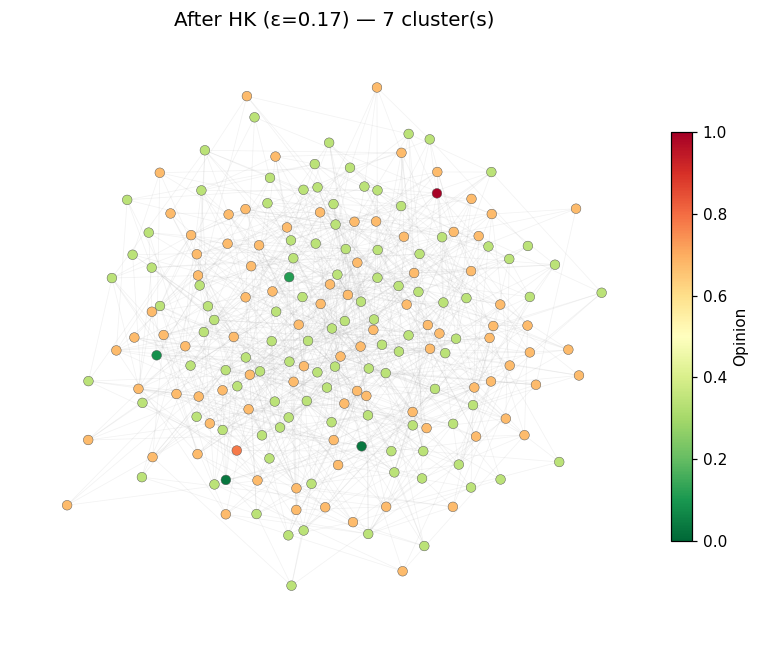

{0: array([ 0.48477126, -0.21046029]),
 1: array([-0.15229073, -0.79938717]),
 2: array([ 0.11500113, -0.24402593]),
 3: array([-0.294237  ,  0.95022302]),
 4: array([-0.48727886, -0.12327965]),
 5: array([-0.46163077,  0.23595052]),
 6: array([-0.91011343, -0.67952761]),
 7: array([ 0.03954634, -0.27457432]),
 8: array([0.25987414, 0.79975958]),
 9: array([0.53312757, 0.35136485]),
 10: array([0.3745366, 0.3883049]),
 11: array([ 0.80695436, -0.05977517]),
 12: array([-0.61733903, -0.48779155]),
 13: array([-0.2579955 , -0.58068113]),
 14: array([-0.00271788,  0.02465097]),
 15: array([ 0.38517479, -0.07366197]),
 16: array([-0.43814863,  0.73458375]),
 17: array([0.29336297, 0.17045672]),
 18: array([-0.12504562, -0.69830924]),
 19: array([-0.36650863, -0.71554254]),
 20: array([ 0.01822772, -0.51933058]),
 21: array([-0.36682772, -0.14130418]),
 22: array([0.15138016, 0.98476405]),
 23: array([0.25319613, 0.11978912]),
 24: array([ 0.49076647, -0.40573565]),
 25: array([0.04465358, 

In [ ]:
epsilon = 0.17

result_ek_polarization = run_simulation(
    graph_ER,
    epsilon      = epsilon,
    rewire       = False,   # without rewiring
    max_hk_steps = 6000,
    seed         = 42,
)

op_initial  = result_ek_polarization["snapshots"][0][1]
op_converged = result_ek_polarization["snapshots"][1][1]

print(f"ε = {epsilon}")
print(f"Steps to convergence: {result_ek_polarization['phases'][0]['steps']}")
print(f"Opinion clusters: {n_clusters(op_converged)}")
print(f"Final variance: {opinion_variance(op_converged):.4f}")
print(f"Polarization Index: {polarization_index(op_converged):.4f}  (0=consenso, 1=máximo)")

plot_network_opinion(
    result_ek_polarization["G"],
    opinions = op_converged,
    title    = f"After HK (ε={epsilon}) — {n_clusters(op_converged)} cluster(s)",
    pos      = pos,
)

Graficando 251 iteraciones reales para ε = 0.05...


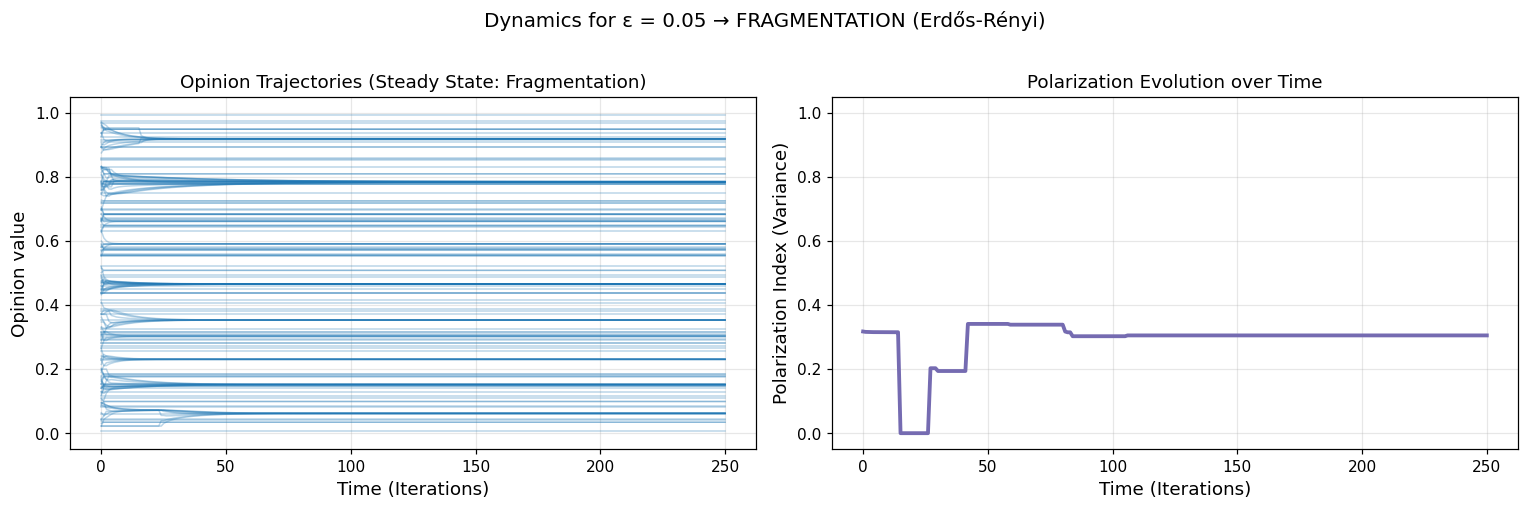

Graficando 118 iteraciones reales para ε = 0.10...


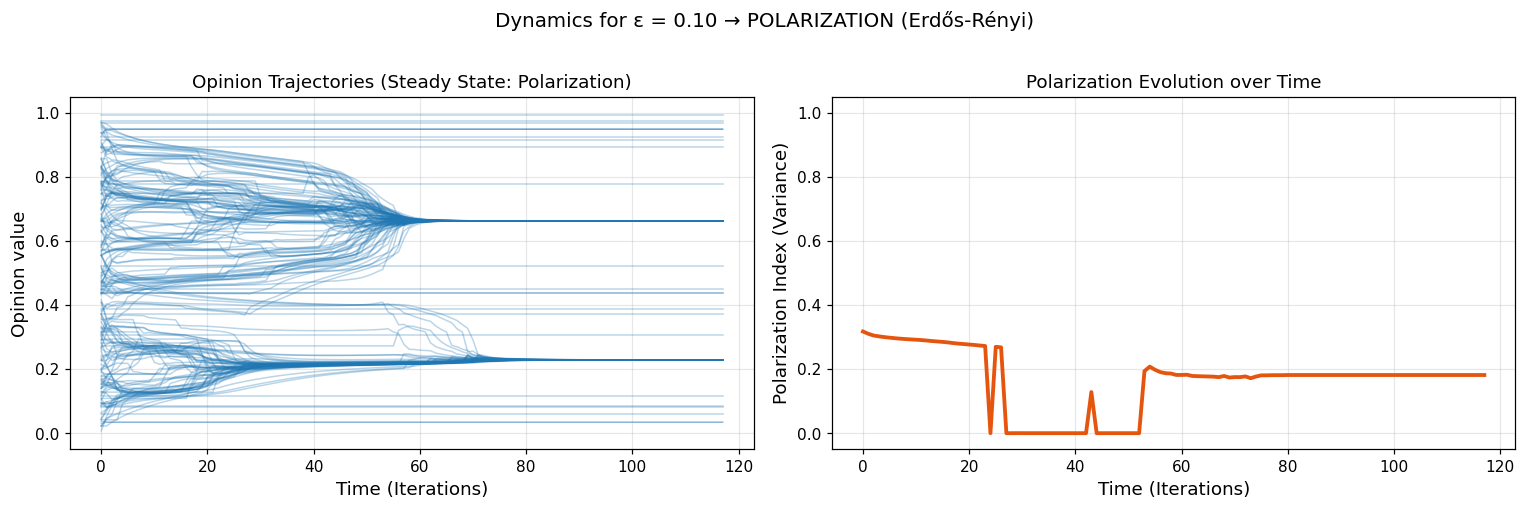

Graficando 129 iteraciones reales para ε = 0.17...


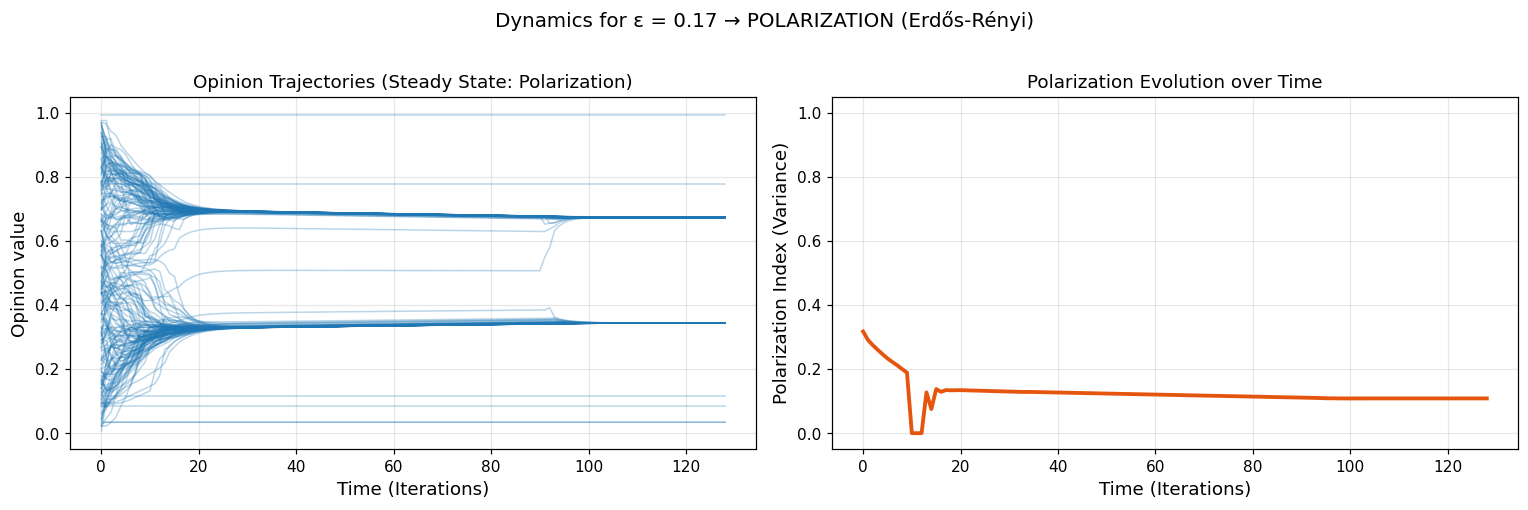

Graficando 43 iteraciones reales para ε = 0.20...


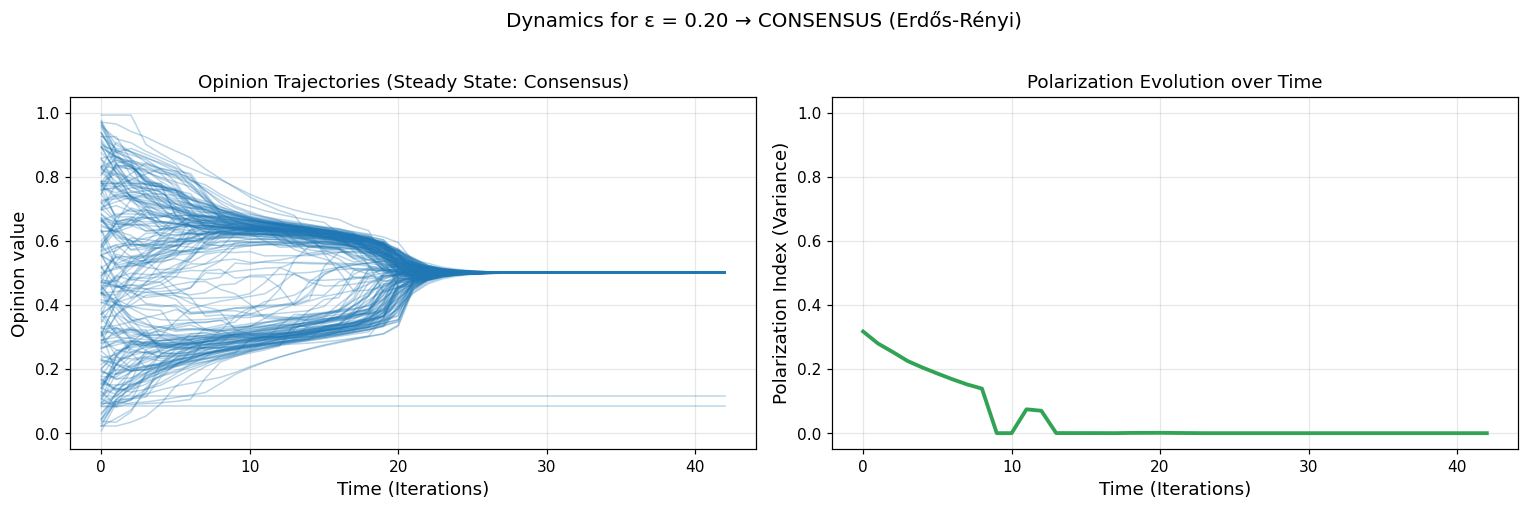

In [ ]:
# =====================================================================
# EJECUTAR LAS TRES CONFIGURACIONES INTERESANTES
# =====================================================================

# 1. Fragmentación (ε = 0.10)
plot_temporal_dynamics(graph_ER, epsilon_val=0.05, regimen_name="Fragmentation", color_var="#756bb1")

# 2. Polarización (ε = 0.25)
plot_temporal_dynamics(graph_ER, epsilon_val=0.17, regimen_name="Polarization", color_var="#e6550d")

# 3. Consenso (ε = 0.35)
plot_temporal_dynamics(graph_ER, epsilon_val=0.2, regimen_name="Consensus", color_var="#31a354")

# BA Network

In [ ]:
graph_BA = make_network(
    model   = "BA",
    n       = 200,
    m       = 3,
    opinion = "uniform",
    seed    = 42,
)

print(f"Nodes: {graph_BA.number_of_nodes()}")
print(f"Edges: {graph_BA.number_of_edges()}")
print(f"Graph average: {np.mean([d for _, d in graph_BA.degree()]):.2f}")
print(f"Initial average opinion: {get_opinions(graph_BA).mean():.3f}")
print(f"Initial variance: {get_opinions(graph_BA).var():.3f}")

Nodes: 200
Edges: 591
Graph average: 5.91
Initial average opinion: 0.494
Initial variance: 0.079


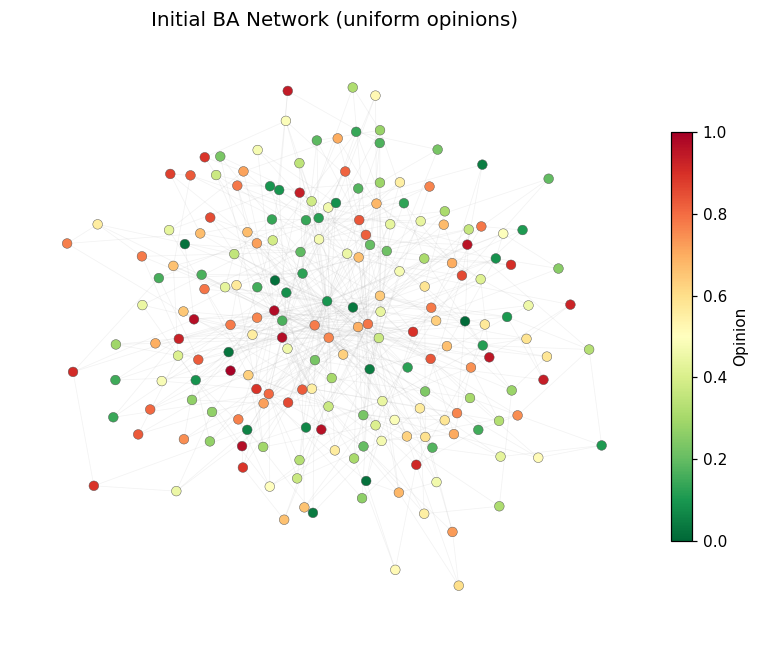

In [ ]:
pos = plot_network_opinion(graph_BA, title="Initial BA Network (uniform opinions)", layout="spring")

--------------------------------------------------
-> La POLARIZACIÓN MACRO (2 clústeres significativos) comienza en ε = 0.15
-> El CONSENSO MACRO (1 clúster mayoritario) se alcanza en ε = 0.2
--------------------------------------------------


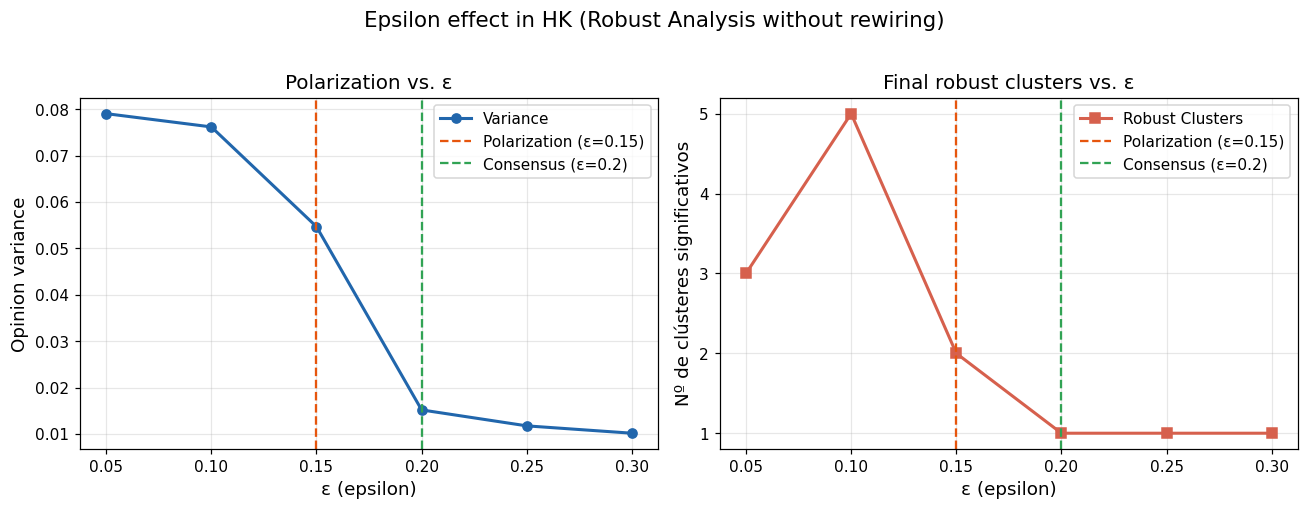

In [ ]:
# =====================================================================
# SIMULACIÓN ACTUALIZADA CON FILTRO ROBUSTO
# =====================================================================
epsilons = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
variances = []
num_clusters = []

for eps in epsilons:
    r = run_simulation(graph_BA, epsilon=eps, rewire=False, max_hk_steps=6000, seed=42)
    final_op = r["snapshots"][-1][1]
    variances.append(opinion_variance(final_op))
    
    # !!! AQUÍ USAMOS LA NUEVA FUNCIÓN ROBUSTA (Masa mínima: 5% de la red)
    num_clusters.append(n_robust_clusters(final_op, min_size_pct=0.05))

# --- LÓGICA PARA DETECTAR LOS PUNTOS DE INFLEXIÓN ---
eps_polarization = None
eps_consensus = None

for eps, clusters in zip(epsilons, num_clusters):
    if clusters == 2 and eps_polarization is None:
        eps_polarization = eps
    if clusters == 1 and eps_consensus is None:
        eps_consensus = eps

# Imprimir los resultados por consola
print("-" * 50)
if eps_polarization is not None:
    print(f"-> La POLARIZACIÓN MACRO (2 clústeres significativos) comienza en ε = {eps_polarization}")
else:
    print("-> No se detectó un estado de polarización real (mitades significativas) con estos epsilons.")

if eps_consensus is not None:
    print(f"-> El CONSENSO MACRO (1 clúster mayoritario) se alcanza en ε = {eps_consensus}")
else:
    print("-> No se alcanzó el consenso macro con estos epsilons.")
print("-" * 50)

# --- GRÁFICOS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfico 1: Varianza
ax1.plot(epsilons, variances, "o-", color="#2166ac", linewidth=2, label="Variance")
ax1.set_xlabel("ε (epsilon)", fontsize=12)
ax1.set_ylabel("Opinion variance", fontsize=12)
ax1.set_title("Polarization vs. ε", fontsize=13)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Número de Clusters
ax2.plot(epsilons, num_clusters, "s-", color="#d6604d", linewidth=2, label="Robust Clusters")
ax2.set_xlabel("ε (epsilon)", fontsize=12)
ax2.set_ylabel("Nº de clústeres significativos", fontsize=12)
ax2.set_title("Final robust clusters vs. ε", fontsize=13)
ax2.yaxis.get_major_locator().set_params(integer=True)
ax2.grid(True, alpha=0.3)

# --- AÑADIR LÍNEAS VERTICALES EN AMBOS GRÁFICOS ---
for ax in [ax1, ax2]:
    if eps_polarization is not None:
        ax.axvline(x=eps_polarization, color="#e6550d", linestyle="--", linewidth=1.5, 
                   label=f"Polarization (ε={eps_polarization})")
    if eps_consensus is not None:
        ax.axvline(x=eps_consensus, color="#31a354", linestyle="--", linewidth=1.5, 
                   label=f"Consensus (ε={eps_consensus})")

ax1.legend(loc="best")
ax2.legend(loc="best")

plt.suptitle("Epsilon effect in HK (Robust Analysis without rewiring)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

--------------------------------------------------
-> La POLARIZACIÓN MACRO (2 clústeres significativos) comienza en ε = 0.14
-> El CONSENSO MACRO (1 clúster mayoritario) se alcanza en ε = 0.17
--------------------------------------------------


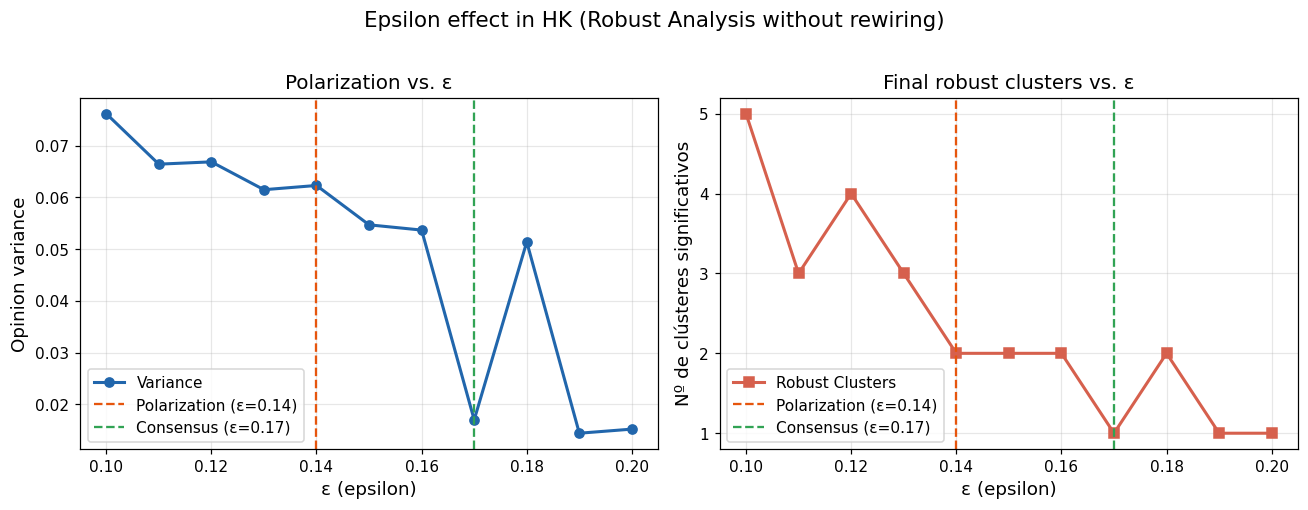

In [ ]:
# =====================================================================
# SIMULACIÓN ACTUALIZADA CON FILTRO ROBUSTO
# =====================================================================
epsilons = [0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2]
variances = []
num_clusters = []

for eps in epsilons:
    r = run_simulation(graph_BA, epsilon=eps, rewire=False, max_hk_steps=6000, seed=42)
    final_op = r["snapshots"][-1][1]
    variances.append(opinion_variance(final_op))
    
    # !!! AQUÍ USAMOS LA NUEVA FUNCIÓN ROBUSTA (Masa mínima: 5% de la red)
    num_clusters.append(n_robust_clusters(final_op, min_size_pct=0.05))

# --- LÓGICA PARA DETECTAR LOS PUNTOS DE INFLEXIÓN ---
eps_polarization = None
eps_consensus = None

for eps, clusters in zip(epsilons, num_clusters):
    if clusters == 2 and eps_polarization is None:
        eps_polarization = eps
    if clusters == 1 and eps_consensus is None:
        eps_consensus = eps

# Imprimir los resultados por consola
print("-" * 50)
if eps_polarization is not None:
    print(f"-> La POLARIZACIÓN MACRO (2 clústeres significativos) comienza en ε = {eps_polarization}")
else:
    print("-> No se detectó un estado de polarización real (mitades significativas) con estos epsilons.")

if eps_consensus is not None:
    print(f"-> El CONSENSO MACRO (1 clúster mayoritario) se alcanza en ε = {eps_consensus}")
else:
    print("-> No se alcanzó el consenso macro con estos epsilons.")
print("-" * 50)

# --- GRÁFICOS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfico 1: Varianza
ax1.plot(epsilons, variances, "o-", color="#2166ac", linewidth=2, label="Variance")
ax1.set_xlabel("ε (epsilon)", fontsize=12)
ax1.set_ylabel("Opinion variance", fontsize=12)
ax1.set_title("Polarization vs. ε", fontsize=13)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Número de Clusters
ax2.plot(epsilons, num_clusters, "s-", color="#d6604d", linewidth=2, label="Robust Clusters")
ax2.set_xlabel("ε (epsilon)", fontsize=12)
ax2.set_ylabel("Nº de clústeres significativos", fontsize=12)
ax2.set_title("Final robust clusters vs. ε", fontsize=13)
ax2.yaxis.get_major_locator().set_params(integer=True)
ax2.grid(True, alpha=0.3)

# --- AÑADIR LÍNEAS VERTICALES EN AMBOS GRÁFICOS ---
for ax in [ax1, ax2]:
    if eps_polarization is not None:
        ax.axvline(x=eps_polarization, color="#e6550d", linestyle="--", linewidth=1.5, 
                   label=f"Polarization (ε={eps_polarization})")
    if eps_consensus is not None:
        ax.axvline(x=eps_consensus, color="#31a354", linestyle="--", linewidth=1.5, 
                   label=f"Consensus (ε={eps_consensus})")

ax1.legend(loc="best")
ax2.legend(loc="best")

plt.suptitle("Epsilon effect in HK (Robust Analysis without rewiring)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

--------------------------------------------------
-> La POLARIZACIÓN MACRO (2 clústeres significativos) comienza en ε = 0.16
-> El CONSENSO MACRO (1 clúster mayoritario) se alcanza en ε = 0.162
--------------------------------------------------


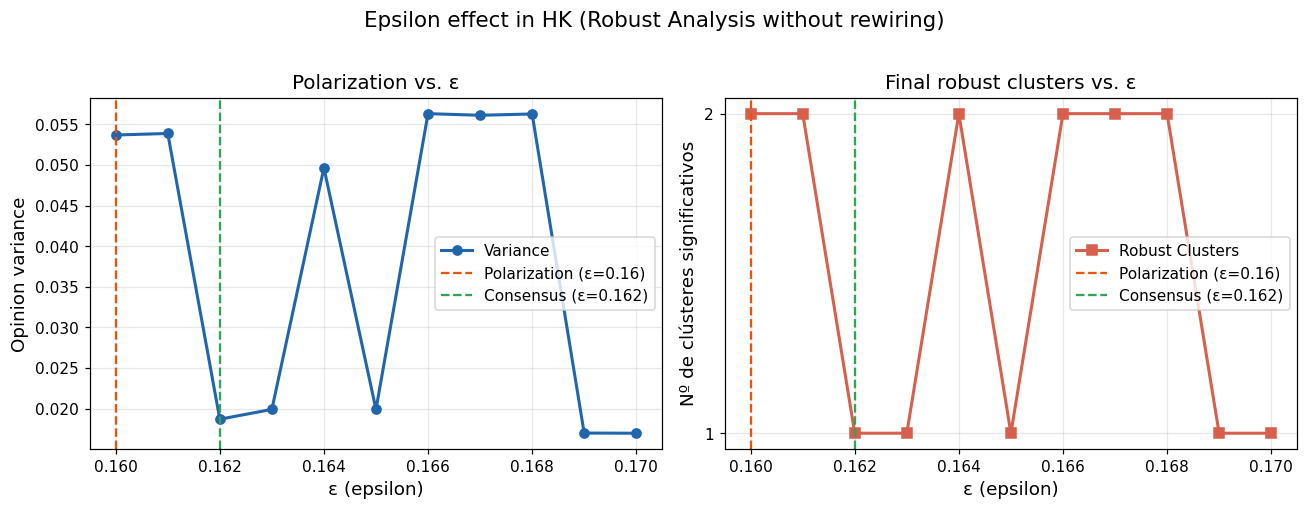

In [ ]:
epsilons = [0.16, 0.161, 0.162, 0.163, 0.164, 0.165, 0.166, 0.167, 0.168, 0.169, 0.17]
variances = []
num_clusters = []

for eps in epsilons:
    r = run_simulation(graph_BA, epsilon=eps, rewire=False, max_hk_steps=6000, seed=42)
    final_op = r["snapshots"][-1][1]
    variances.append(opinion_variance(final_op))
    
    num_clusters.append(n_robust_clusters(final_op, min_size_pct=0.05))

# --- LÓGICA PARA DETECTAR LOS PUNTOS DE INFLEXIÓN ---
eps_polarization = None
eps_consensus = None

for eps, clusters in zip(epsilons, num_clusters):
    if clusters == 2 and eps_polarization is None:
        eps_polarization = eps
    if clusters == 1 and eps_consensus is None:
        eps_consensus = eps

# Imprimir los resultados por consola
print("-" * 50)
if eps_polarization is not None:
    print(f"-> La POLARIZACIÓN MACRO (2 clústeres significativos) comienza en ε = {eps_polarization}")
else:
    print("-> No se detectó un estado de polarización real (mitades significativas) con estos epsilons.")

if eps_consensus is not None:
    print(f"-> El CONSENSO MACRO (1 clúster mayoritario) se alcanza en ε = {eps_consensus}")
else:
    print("-> No se alcanzó el consenso macro con estos epsilons.")
print("-" * 50)

# --- GRÁFICOS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfico 1: Varianza
ax1.plot(epsilons, variances, "o-", color="#2166ac", linewidth=2, label="Variance")
ax1.set_xlabel("ε (epsilon)", fontsize=12)
ax1.set_ylabel("Opinion variance", fontsize=12)
ax1.set_title("Polarization vs. ε", fontsize=13)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Número de Clusters
ax2.plot(epsilons, num_clusters, "s-", color="#d6604d", linewidth=2, label="Robust Clusters")
ax2.set_xlabel("ε (epsilon)", fontsize=12)
ax2.set_ylabel("Nº de clústeres significativos", fontsize=12)
ax2.set_title("Final robust clusters vs. ε", fontsize=13)
ax2.yaxis.get_major_locator().set_params(integer=True)
ax2.grid(True, alpha=0.3)

for ax in [ax1, ax2]:
    if eps_polarization is not None:
        ax.axvline(x=eps_polarization, color="#e6550d", linestyle="--", linewidth=1.5, 
                   label=f"Polarization (ε={eps_polarization})")
    if eps_consensus is not None:
        ax.axvline(x=eps_consensus, color="#31a354", linestyle="--", linewidth=1.5, 
                   label=f"Consensus (ε={eps_consensus})")

ax1.legend(loc="best")
ax2.legend(loc="best")

plt.suptitle("Epsilon effect in HK (Robust Analysis without rewiring)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Graficando 228 iteraciones reales para ε = 0.10...


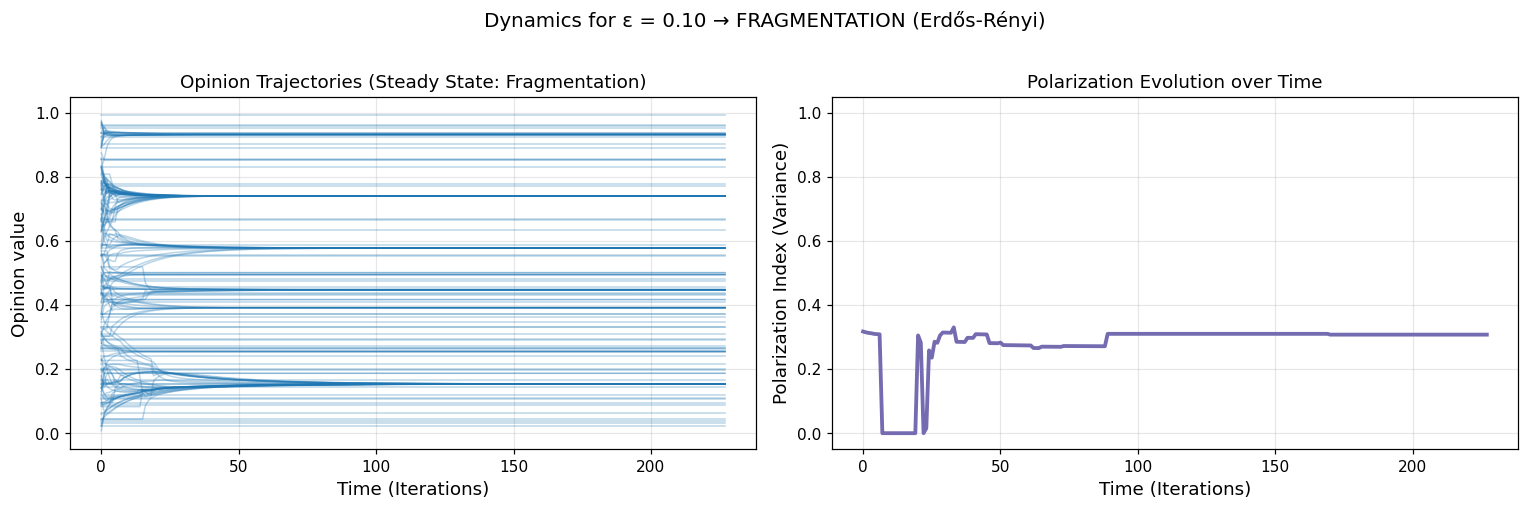

Graficando 157 iteraciones reales para ε = 0.14...


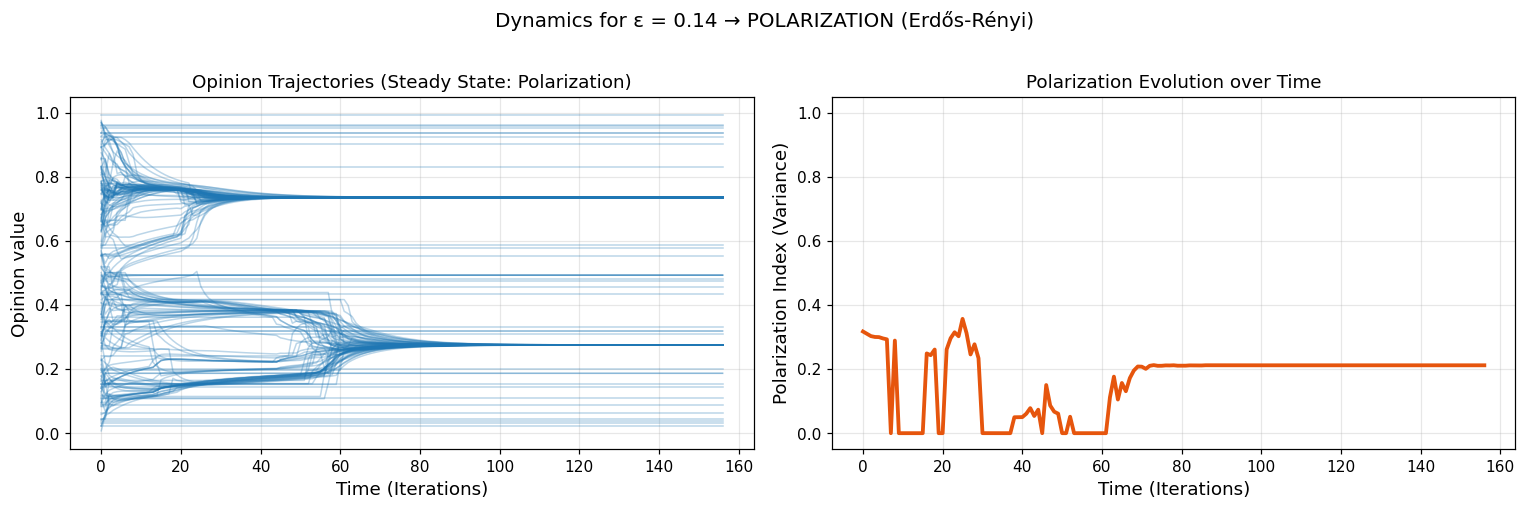

Graficando 483 iteraciones reales para ε = 0.17...


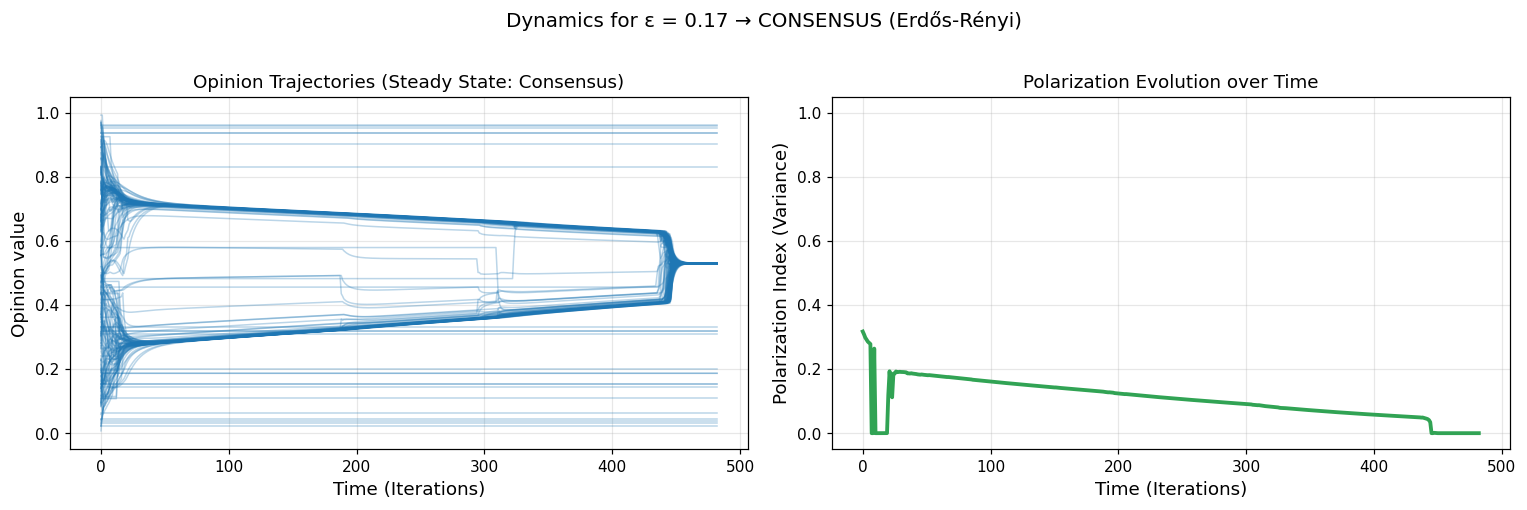

Graficando 127 iteraciones reales para ε = 0.18...


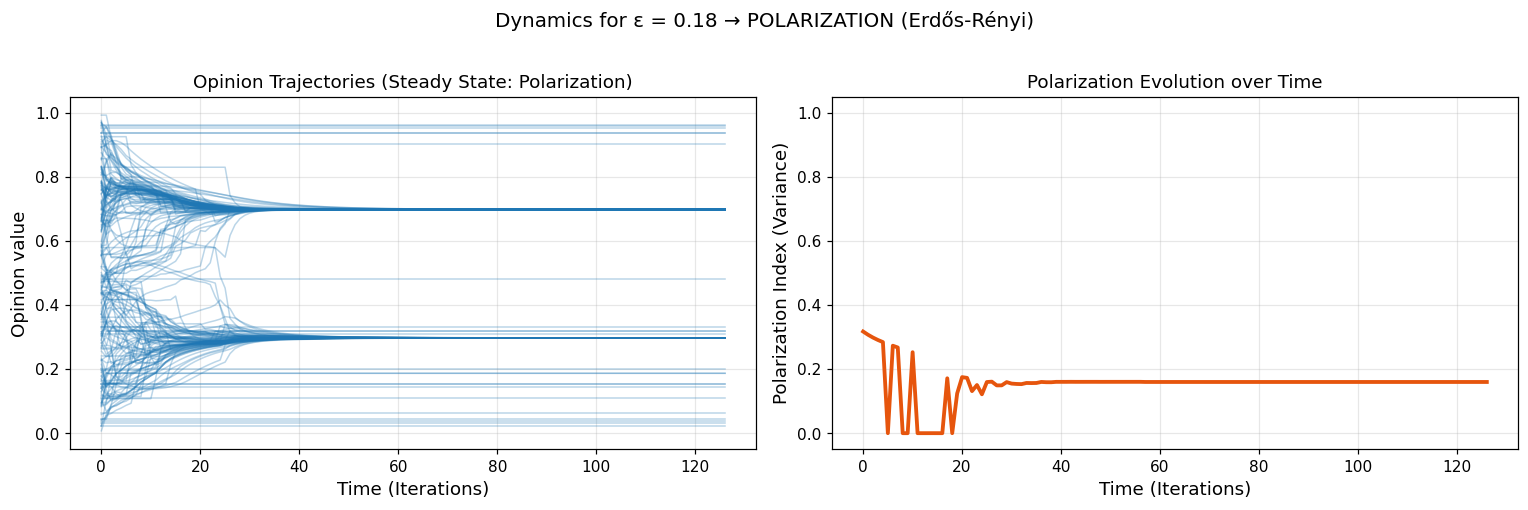

In [ ]:
plot_temporal_dynamics(graph_BA, epsilon_val=0.10, regimen_name="Fragmentation", color_var="#756bb1")

plot_temporal_dynamics(graph_BA, epsilon_val=0.14, regimen_name="Polarization", color_var="#e6550d")

plot_temporal_dynamics(graph_BA, epsilon_val=0.17, regimen_name="Consensus", color_var="#31a354")

plot_temporal_dynamics(graph_BA, epsilon_val=0.18, regimen_name="Polarization", color_var="#e6550d")

ε = 0.16
Steps to convergence: 207
Opinion clusters: 28
Final variance: 0.0537
Polarization Index: 0.2147  (0=consenso, 1=máximo)


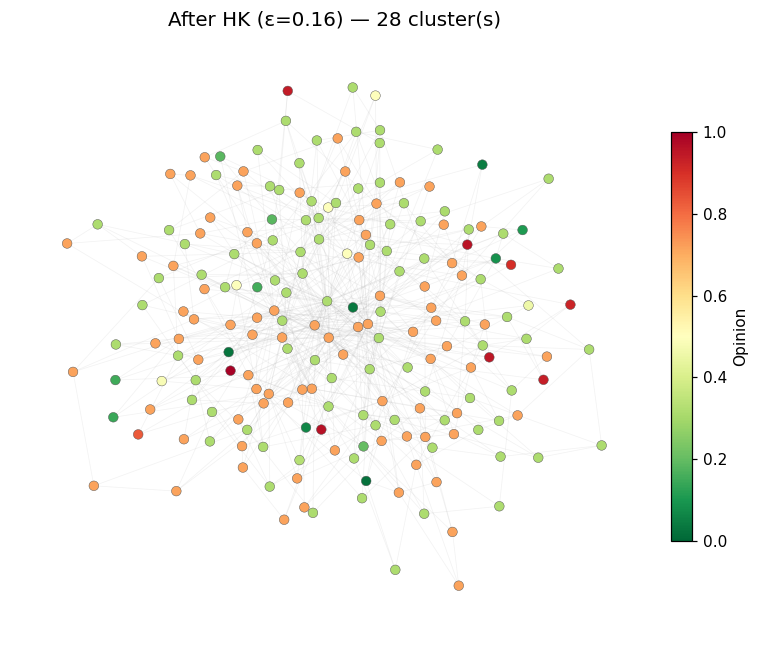

{0: array([-0.07373056, -0.01562609]),
 1: array([0.15390746, 0.03580438]),
 2: array([-0.16552616, -0.3078493 ]),
 3: array([ 0.07622883, -0.02200432]),
 4: array([-0.03058896,  0.07533486]),
 5: array([-0.21329791,  0.03991436]),
 6: array([-0.02519338, -0.06254404]),
 7: array([ 0.11016257, -0.01077144]),
 8: array([-0.11562541,  0.17995265]),
 9: array([0.03861791, 0.25513176]),
 10: array([ 0.14793079, -0.0635182 ]),
 11: array([-0.54286763, -0.06692224]),
 12: array([0.15190451, 0.09575678]),
 13: array([0.10337845, 0.32604988]),
 14: array([ 0.16009761, -0.30221427]),
 15: array([ 0.09425256, -0.35541386]),
 16: array([-0.08341982, -0.2554628 ]),
 17: array([-0.10364677, -0.40209687]),
 18: array([-0.47577169, -0.14563895]),
 19: array([-0.30290514, -0.20413689]),
 20: array([-0.27260863,  0.012995  ]),
 21: array([-0.35140598,  0.25367735]),
 22: array([-0.18607242, -0.06196907]),
 23: array([-0.27477086, -0.25651244]),
 24: array([-0.3645097 , -0.01382313]),
 25: array([-0.122

In [ ]:
epsilon = 0.16

result_BA_polarization = run_simulation(
    graph_BA,
    epsilon      = epsilon,
    rewire       = False,   # without rewiring
    max_hk_steps = 6000,
    seed         = 42,
)

op_initial  = result_BA_polarization["snapshots"][0][1]
op_converged = result_BA_polarization["snapshots"][1][1]

print(f"ε = {epsilon}")
print(f"Steps to convergence: {result_BA_polarization['phases'][0]['steps']}")
print(f"Opinion clusters: {n_clusters(op_converged)}")
print(f"Final variance: {opinion_variance(op_converged):.4f}")
print(f"Polarization Index: {polarization_index(op_converged):.4f}  (0=consenso, 1=máximo)")

plot_network_opinion(
    result_BA_polarization["G"],
    opinions = op_converged,
    title    = f"After HK (ε={epsilon}) — {n_clusters(op_converged)} cluster(s)",
    pos      = pos,
)